In [35]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

In [48]:
# Read the Spotify tracks dataset and display the first 5 rows.
spotify_tracks = pd.read_csv('spotify_tracks.csv')
spotify_tracks.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [49]:
# Check the unique music genres present in the dataset.
spotify_tracks['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [37]:
# Filter the dataset to keep only selected genres for the classification task
spotify_tracks = spotify_tracks[spotify_tracks['track_genre'].isin(['pop', 'country', 'hip-hop', 'punk-rock', 'latin', 'edm'])]

In [44]:
# Remove columns that are not useful for model training.
spotify_tracks.drop(
    columns=["Unnamed: 0", "track_id", "track_name", "artists", "album_name", "time_signature"],
    errors="ignore",
    inplace=True
)

print(spotify_tracks.isnull().sum())

spotify_tracks.dropna(inplace=True)

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64


C:\Users\Ademola\AppData\Local\Temp\ipykernel_11220\696999854.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_tracks.drop(
C:\Users\Ademola\AppData\Local\Temp\ipykernel_11220\696999854.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_tracks.dropna(inplace=True)


In [46]:
# Display the first 5 rows again to confirm the dataset after removing unnecessary columns.
spotify_tracks.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
19000,78,167693,False,0.654,0.630,10,-4.644,1,0.0259,0.153,0.000000,0.1110,0.430,89.991,country
19001,0,236455,False,0.520,0.751,5,-5.064,1,0.0551,0.171,0.000007,0.0624,0.519,156.044,country
19002,1,228320,False,0.590,0.389,2,-9.245,1,0.0387,0.411,0.000001,0.1170,0.389,166.055,country
19003,3,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555,0.000008,0.0954,0.148,175.212,country
19004,4,228013,False,0.369,0.192,4,-12.151,0,0.0400,0.555,0.000008,0.0954,0.148,175.212,country


In [41]:
# Separate the dataset into features (X) and target variable (y).
# X contains all predictor variables while y contains the genre labels.
X, y = spotify_tracks.loc[ : , (spotify_tracks.columns != 'track_genre')], spotify_tracks['track_genre']

# Split the dataset into training and testing sets. 80% of the data is used for training and 20% for testing the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


In [42]:
# Convert categorical genre labels into numerical values.
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train) # Fit and transform training labels
y_val = label_encoder.transform(y_val) # Transform validation labels
y_test = label_encoder.transform(y_test)

In [43]:
# Standardise the feature values to improve model performance for many algorithms
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit scaler on training data
X_val=scaler.transform(X_val) # Apply same scaling to validation data
X_test=scaler.transform(X_test)

In [30]:
# Initialise the XGBoost classifier and train it using the training dataset.
xgb_classifier = xgb.XGBClassifier(random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_val)

test_accuracy = accuracy_score(y_val, y_pred)
print(f"Test accuracy: {test_accuracy: .4f}")

print("\nClassification Report: \n", classification_report(y_val, y_pred))

print("\nConfusion Matrix: \n", confusion_matrix(y_val, y_pred))

Test accuracy:  0.7075

Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.81      0.78       197
           1       0.76      0.74      0.75       208
           2       0.64      0.58      0.61       206
           3       0.70      0.64      0.67       202
           4       0.55      0.63      0.59       185
           5       0.83      0.85      0.84       202

    accuracy                           0.71      1200
   macro avg       0.71      0.71      0.71      1200
weighted avg       0.71      0.71      0.71      1200


Confusion Matrix: 
 [[160   7   3   6   7  14]
 [  8 153   7   8  20  12]
 [  0  18 119  26  41   2]
 [ 15   4  26 130  22   5]
 [ 10  16  27  15 116   1]
 [ 18   4   4   1   4 171]]


In [31]:
# Define a grid of hyperparameters to search for the best model.

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 6, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.05, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0,0.01, 0.1, 1, 10, 100],
    "reg_lambda": [0.5, 0.7, 1, 1.3]
}

xgb_model = xgb.XGBClassifier(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

print("Best Parameter: ", grid_search.best_params_)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Parameter:  {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


In [32]:
# Print the best accuracy score obtained from the grid search during cross-validation.
print("Best Accuracy: ", grid_search.best_score_)

Best Accuracy:  0.7283333333333333


In [33]:
# Use the best trained model to make predictions on the test dataset.
y_pred = best_xgb.predict(X_test)

# calculate the overall accuracy of the model.
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy: .4f}")

print("\nClassification Report: \n", classification_report(y_test, y_pred))

print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))

Test accuracy:  0.7017

Classification Report: 
               precision    recall  f1-score   support

           0       0.75      0.78      0.77       215
           1       0.77      0.71      0.74       222
           2       0.62      0.60      0.61       176
           3       0.69      0.64      0.66       204
           4       0.56      0.64      0.59       189
           5       0.81      0.83      0.82       194

    accuracy                           0.70      1200
   macro avg       0.70      0.70      0.70      1200
weighted avg       0.70      0.70      0.70      1200


Confusion Matrix: 
 [[168   4   4   4  19  16]
 [  7 157  12   4  28  14]
 [  4  10 105  28  27   2]
 [ 24   9  20 130  19   2]
 [  9  14  24  18 121   3]
 [ 11   9   4   5   4 161]]


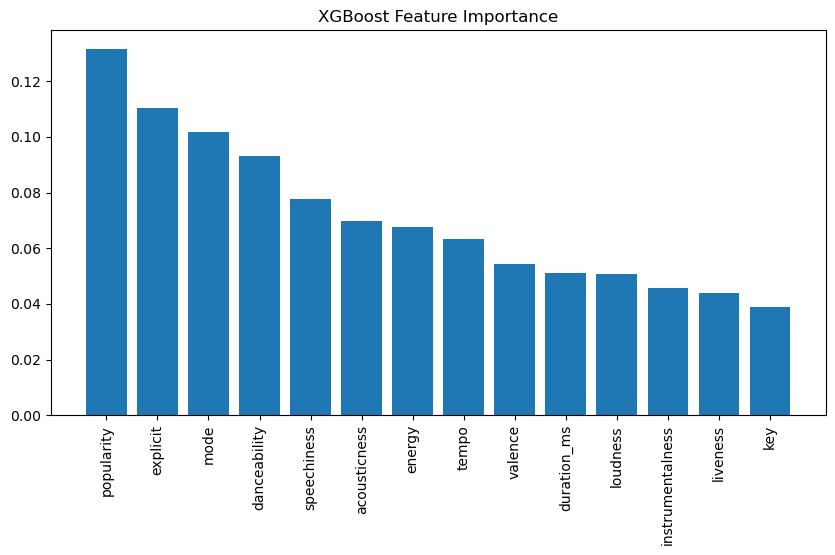

In [51]:
# Use feature importance scores from the trained XGBoost model to identify which features contribute the most to predictions.

# Create a dataframe for feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=90)
plt.title("XGBoost Feature Importance")
plt.show()